# US 4.1.1 — Autoencoder para Imputación de Series Temporales

**Entregable:** Notebook + métricas de desempeño  
**Criterio de aceptación:** Arquitectura entrenada y validada

## Descripción
Implementa un **Autoencoder convolucional 1-D** en PyTorch para la imputación de valores faltantes en series hidrometeorológicas diarias de Sinaloa. El modelo aprende una representación comprimida (espacio latente) de ventanas temporales de 30 días y las reconstruye, imputando las posiciones faltantes.

## Arquitectura
```
Entrada: (N, 30, 4)  — N secuencias, 30 días, 4 variables

Encoder:
  Conv1d(4 → 32, k=3, pad=1)   + BatchNorm + ReLU  → (N, 32, 30)
  Conv1d(32 → 64, k=3, pad=1)  + BatchNorm + ReLU  → (N, 64, 30)
  Conv1d(64 → 128, k=3, pad=1) + BatchNorm + ReLU  → (N, 128, 30)
  AdaptiveAvgPool1d(8)                              → (N, 128, 8)
  Flatten                                           → (N, 1024)
  Linear(1024 → 64)             + ReLU             → (N, 64)   ← espacio latente

Decoder:
  Linear(64 → 1024)            + ReLU              → (N, 1024)
  Unflatten → (N, 128, 8)
  Upsample(size=30, linear)                         → (N, 128, 30)
  Conv1d(128 → 64, k=3, pad=1) + BatchNorm + ReLU  → (N, 64, 30)
  Conv1d(64 → 32, k=3, pad=1)  + BatchNorm + ReLU  → (N, 32, 30)
  Conv1d(32 →  4, k=3, pad=1)                      → (N,  4, 30)

Salida: (N, 30, 4)
```

## Función de pérdida (masked MSE)
```
loss = Σ[(pred - target)² × mask] / Σ[mask]
```
Sólo se penaliza en posiciones con dato real observado (`mask=1`). Las posiciones faltantes originales no contribuyen al gradiente.

## Evaluación MCAR
En el test set se enmascara artificialmente el 20% de los valores observados y se mide la calidad de la reconstrucción.

## Métricas de evaluación
| Métrica | Descripción |
|---------|-------------|
| RMSE / MAE / MAPE | Error puntual en espacio escalado |
| R² / NSE | Bondad de ajuste (NSE > 0: supera la media; NSE > 0.6: buen resultado) |
| KPSS | Estacionariedad: H₀ serie estacionaria — se verifica que imputado y original coincidan |
| ACF/PACF | Estructura temporal: los coeficientes (21 lags) deben ser similares entre original e imputado |

In [1]:
from pathlib import Path
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ─── Raíz del proyecto ───────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
MODELS_DIR   = PROJECT_ROOT / "models" / "modelos_base"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_base"
FIGURES_DIR  = REPORTS_DIR / "figuras"
for d in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"PROJECT : {PROJECT_ROOT}")

Device  : cpu
PyTorch : 2.11.0+cu130
PROJECT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main


## 1 — Carga de tensores

In [2]:
def load_tensor(path: Path) -> torch.Tensor:
    try:
        return torch.load(path, weights_only=True)
    except TypeError:
        return torch.load(path)

X_train = load_tensor(TENSORS_DIR / "X_train.pt")
M_train = load_tensor(TENSORS_DIR / "mask_train.pt")
X_val   = load_tensor(TENSORS_DIR / "X_val.pt")
M_val   = load_tensor(TENSORS_DIR / "mask_val.pt")
X_test  = load_tensor(TENSORS_DIR / "X_test.pt")
M_test  = load_tensor(TENSORS_DIR / "mask_test.pt")

print(f"X_train : {tuple(X_train.shape)}  |  obs_rate={M_train.mean():.3f}")
print(f"X_val   : {tuple(X_val.shape)}  |  obs_rate={M_val.mean():.3f}")
print(f"X_test  : {tuple(X_test.shape)}  |  obs_rate={M_test.mean():.3f}")

# Cargamos metadatos de los tensores
with open(TENSORS_DIR / "tensors_metadata.json") as f:
    meta = json.load(f)
print(f"\nWindow size : {meta['config']['window_size']}")
print(f"Variables   : {meta['feature_names']}")
print(f"N estaciones: {meta['n_estaciones']}")

X_train : (160041, 30, 4)  |  obs_rate=0.857
X_val   : (33831, 30, 4)  |  obs_rate=0.915
X_test  : (33678, 30, 4)  |  obs_rate=0.865

Window size : 30
Variables   : ['precip', 'evap', 'tmax', 'tmin']
N estaciones: 173


In [3]:
# Hiperparámetros de entrenamiento
BATCH_SIZE  = 256
EPOCHS      = 60
LR          = 1e-3
LATENT_DIM  = 64
PATIENCE    = 10        # early stopping
MCAR_RATE   = 0.20      # fracción MCAR para evaluación

N_FEAT   = X_train.shape[2]   # 4
WIN_SIZE = X_train.shape[1]   # 30

# DataLoaders
train_ds = TensorDataset(X_train, M_train)
val_ds   = TensorDataset(X_val,   M_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=(DEVICE=='cuda'))

print(f"Batches train: {len(train_loader)}  |  val: {len(val_loader)}")

Batches train: 626  |  val: 133


## 2 — Arquitectura del Autoencoder

In [4]:
class ConvAutoencoder(nn.Module):
    """
    Autoencoder convolucional 1-D para imputación de series temporales.

    Entrada : (N, T, F)  — N secuencias, T pasos temporales, F features
    Salida  : (N, T, F)  — reconstrucción completa de la secuencia

    Internamente trabaja en formato (N, F, T) como requiere Conv1d.
    """

    def __init__(self, n_features: int = 4, window: int = 30,
                 latent_dim: int = 64):
        super().__init__()
        self.n_features = n_features
        self.window     = window
        self.latent_dim = latent_dim

        # Encoder: (N, F, T) → (N, latent_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),          # (N, 128, 8)
            nn.Flatten(),                     # (N, 1024)
            nn.Linear(128 * 8, latent_dim),
            nn.ReLU(),
        )

        # Decoder: (N, latent_dim) → (N, F, T)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8)),        # (N, 128, 8)
            nn.Upsample(size=window, mode='linear', align_corners=False),  # (N,128,T)
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, n_features, kernel_size=3, padding=1),  # (N, F, T)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (N, T, F) → permute → (N, F, T)
        x = x.permute(0, 2, 1)
        z = self.encoder(x)
        out = self.decoder(z)
        return out.permute(0, 2, 1)  # (N, T, F)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x.permute(0, 2, 1))


def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor,
                    mask: torch.Tensor) -> torch.Tensor:
    """MSE sólo sobre posiciones observadas (mask=1)."""
    sq_err = (pred - target) ** 2
    return (sq_err * mask).sum() / (mask.sum() + 1e-8)


# Instanciar y mover a dispositivo
model = ConvAutoencoder(n_features=N_FEAT, window=WIN_SIZE,
                        latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total_params:,}")
print(model)

Parámetros totales: 195,332
ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(4, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=8)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=1024, out_features=64, bias=True)
    (12): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=1024, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(128, 8))
    (3): Upsample(size=30, mode='linear')
    (4): Conv1d(128, 64, kernel_size=(3,

## 3 — Entrenamiento

Protocolo de entrenamiento por denoising MCAR:
- **Optimizador:** Adam (lr=1e-3, weight_decay=1e-5) con ReduceLROnPlateau (factor=0.5, patience=5)
- **Épocas:** 60 máximo · **Early stopping:** patience=10 sobre val_loss
- **Grad clipping:** norm=1.0 para estabilidad del gradiente
- **Estrategia:** en cada batch se enmascara aleatoriamente el 20 % de los valores observados (MCAR) → el modelo recibe la secuencia con esos valores en cero y se penaliza únicamente en las posiciones enmascaradas (Masked MSE). Las posiciones faltantes originales no contribuyen al gradiente.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0
best_state = None

print(f"{'Época':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'LR':>10}  {'Tiempo':>8}")
print('─' * 58)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ─── Entrenamiento ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_batch, M_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        M_batch = M_batch.to(DEVICE)
        optimizer.zero_grad()

        # Denoising: MCAR masking en entrenamiento.
        # El autoencoder aprende a reconstruir posiciones enmascaradas
        # a partir de la estructura global de la secuencia Conv1D.
        rand       = torch.rand_like(M_batch)
        mcar_pos   = M_batch * (rand <= MCAR_RATE).float()  # posiciones a imputar
        input_mask = M_batch * (rand >  MCAR_RATE).float()  # posiciones visibles
        X_input    = X_batch * input_mask

        pred = model(X_input)
        loss = masked_mse_loss(pred, X_batch, mcar_pos)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # ─── Validación ──────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, M_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            M_batch = M_batch.to(DEVICE)
            rand       = torch.rand_like(M_batch)
            mcar_pos   = M_batch * (rand <= MCAR_RATE).float()
            input_mask = M_batch * (rand >  MCAR_RATE).float()
            X_input    = X_batch * input_mask
            pred = model(X_input)
            loss = masked_mse_loss(pred, X_batch, mcar_pos)
            val_loss += loss.item() * len(X_batch)
    val_loss /= len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']

    elapsed = time.time() - t0
    print(f"{epoch:>6}  {train_loss:>12.6f}  {val_loss:>10.6f}  "
          f"{lr_now:>10.2e}  {elapsed:>6.1f}s")

    # ─── Early stopping ──────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping en época {epoch} (sin mejora en {PATIENCE} épocas).")
            break

model.load_state_dict(best_state)
print(f"\nMejor val_loss: {best_val_loss:.6f}")

 Época    Train Loss    Val Loss          LR    Tiempo
──────────────────────────────────────────────────────────
     1      0.086228    0.075201    1.00e-03    16.4s
     2      0.073967    0.074442    1.00e-03    16.3s
     3      0.071049    0.074499    1.00e-03    16.3s
     4      0.069681    0.069933    1.00e-03    16.3s
     5      0.068308    0.069306    1.00e-03    16.3s
     6      0.067451    0.072894    1.00e-03    16.4s
     7      0.066668    0.070212    1.00e-03    16.7s
     8      0.066219    0.066661    1.00e-03    17.3s
     9      0.065302    0.068402    1.00e-03    16.9s
    10      0.064819    0.069349    1.00e-03    16.9s
    11      0.064699    0.067667    1.00e-03    16.8s
    12      0.064063    0.065187    1.00e-03    16.7s
    13      0.063804    0.064698    1.00e-03    16.7s
    14      0.063560    0.064205    1.00e-03    16.9s
    15      0.063065    0.063946    1.00e-03    18.1s
    16      0.062972    0.066059    1.00e-03    18.9s
    17      0.062706  

Modelo guardado en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/models/modelos_base/autoencoder_best.pt


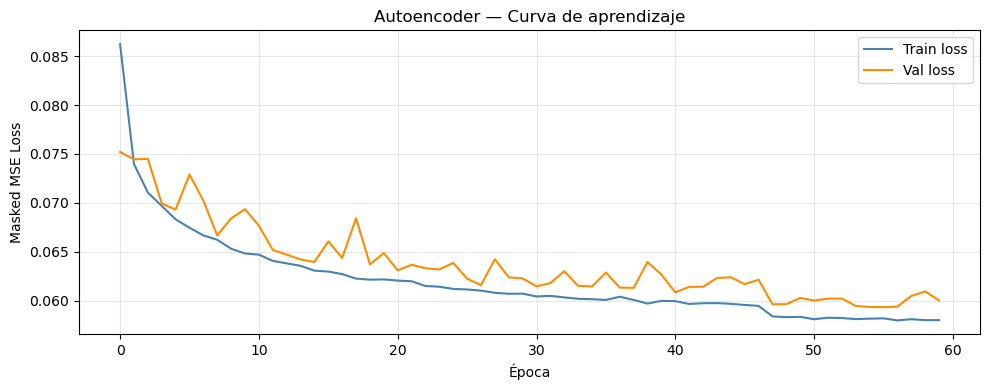

In [6]:
# Guardar modelo entrenado
model_path = MODELS_DIR / "autoencoder_best.pt"
torch.save({'model_state_dict': model.state_dict(),
            'config': {'n_features': N_FEAT, 'window': WIN_SIZE,
                       'latent_dim': LATENT_DIM},
            'best_val_loss': best_val_loss}, model_path)
print(f"Modelo guardado en: {model_path}")

# Curva de aprendizaje
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train loss', color='steelblue')
ax.plot(history['val_loss'],   label='Val loss',   color='darkorange')
ax.set_xlabel('Época')
ax.set_ylabel('Masked MSE Loss')
ax.set_title('Autoencoder — Curva de aprendizaje')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_learning_curve.png", dpi=120, bbox_inches='tight')
plt.show()

## 4 — Evaluación MCAR en test set

Protocolo estándar MCAR 20 % aplicado al test set:
1. Se seleccionan secuencias con ≥ 70 % de observaciones reales.
2. Se enmascara artificialmente el 20 % de esas observaciones.
3. El modelo recibe la secuencia con los valores enmascarados en cero.
4. Las métricas se calculan **solo** sobre las posiciones artificialmente enmascaradas.
5. La salida es determinista (una única reconstrucción por secuencia, a diferencia del VAE).

In [8]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, var_name: str) -> dict:
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)
    r2   = float(r2_score(y_true, y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    nse  = float(1 - ss_res / (ss_tot + eps))
    return {"variable": var_name, "rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "nse": nse}


@torch.no_grad()
def evaluate_mcar(model: nn.Module,
                  X_test: torch.Tensor,
                  M_test: torch.Tensor,
                  mcar_rate: float = 0.20,
                  min_obs_rate: float = 0.70,
                  batch_size: int = 512) -> dict:
    """
    Protocolo MCAR:
    1. Filtra secuencias con obs_rate >= min_obs_rate.
    2. Enmascara aleatoriamente mcar_rate de los valores observados.
    3. Pasa las secuencias modificadas por el modelo.
    4. Calcula métricas en las posiciones artificialmente enmascaradas.

    Returns: dict {var_name: metrics_dict}
    """
    torch.manual_seed(42)
    model.eval()
    model.to(DEVICE)

    # Filtrar secuencias con alta tasa de observación
    obs_rate = M_test.mean(dim=(1, 2))           # (N,)
    sel      = obs_rate >= min_obs_rate
    X_sel    = X_test[sel]
    M_sel    = M_test[sel]
    N_sel    = X_sel.shape[0]
    print(f"  Secuencias con obs≥{min_obs_rate*100:.0f}%: {N_sel:,} / {X_test.shape[0]:,}")

    # Crear máscara MCAR: enmascarar mcar_rate de posiciones observadas
    rand = torch.rand_like(M_sel)               # uniforme [0,1)
    # eval_mask: posiciones que SE MUESTRAN al modelo (observadas no enmascaradas)
    eval_mask = M_sel * (rand > mcar_rate).float()
    # gt_mask: posiciones que SE EVALÚAN (observadas enmascaradas artificialmente)
    gt_mask   = M_sel * (rand <= mcar_rate).float()

    X_masked = X_sel * eval_mask               # NaN artificiales → 0

    # Inferencia por batches
    all_preds = []
    ds = TensorDataset(X_masked, eval_mask)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    for X_b, _ in loader:
        pred_b = model(X_b.to(DEVICE)).cpu()
        all_preds.append(pred_b)
    preds = torch.cat(all_preds, dim=0)        # (N_sel, T, F)

    # Métricas por variable
    results = {}
    for fi, var in enumerate(VARIABLES):
        gt_mask_var = gt_mask[:, :, fi].bool()  # (N_sel, T)
        y_true = X_sel[:, :, fi][gt_mask_var].numpy()
        y_pred = preds[:, :, fi][gt_mask_var].numpy()

        n_pts = len(y_true)
        print(f"  {var}: {n_pts:,} puntos MCAR")
        m = compute_metrics(y_true, y_pred, var)
        m["n_mcar"] = n_pts
        results[var] = m
    return results, preds, X_sel, eval_mask, gt_mask


print("Evaluando Autoencoder en test set (MCAR 20%)...")
ae_eval, preds, Xs, ev_m, gt_m = evaluate_mcar(model, X_test, M_test, mcar_rate=MCAR_RATE)

print("\n─── Métricas Autoencoder ───")
for var, m in ae_eval.items():
    print(f"  {var:6s}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  "
          f"MAPE={m['mape']:.2f}%  R²={m['r2']:.4f}  NSE={m['nse']:.4f}")

# Guardar referencias para KPSS (cell[14] sobreescribe Xs y ev_m)
_ae_preds, _ae_Xs, _ae_ev_m = preds, Xs, ev_m

Evaluando Autoencoder en test set (MCAR 20%)...
  Secuencias con obs≥70%: 32,661 / 33,678
  precip: 196,368 puntos MCAR
  evap: 100,832 puntos MCAR
  tmax: 195,614 puntos MCAR
  tmin: 195,037 puntos MCAR

─── Métricas Autoencoder ───
  precip  RMSE=0.0222  MAE=0.0083  MAPE=40165336.00%  R²=0.0664  NSE=0.0664
  evap    RMSE=0.0580  MAE=0.0411  MAPE=256668.50%  R²=0.6628  NSE=0.6628
  tmax    RMSE=0.3917  MAE=0.2781  MAPE=82.14%  R²=0.8486  NSE=0.8486
  tmin    RMSE=0.2561  MAE=0.1846  MAPE=54.54%  R²=0.9365  NSE=0.9365


## 5 — Visualización de reconstrucciones

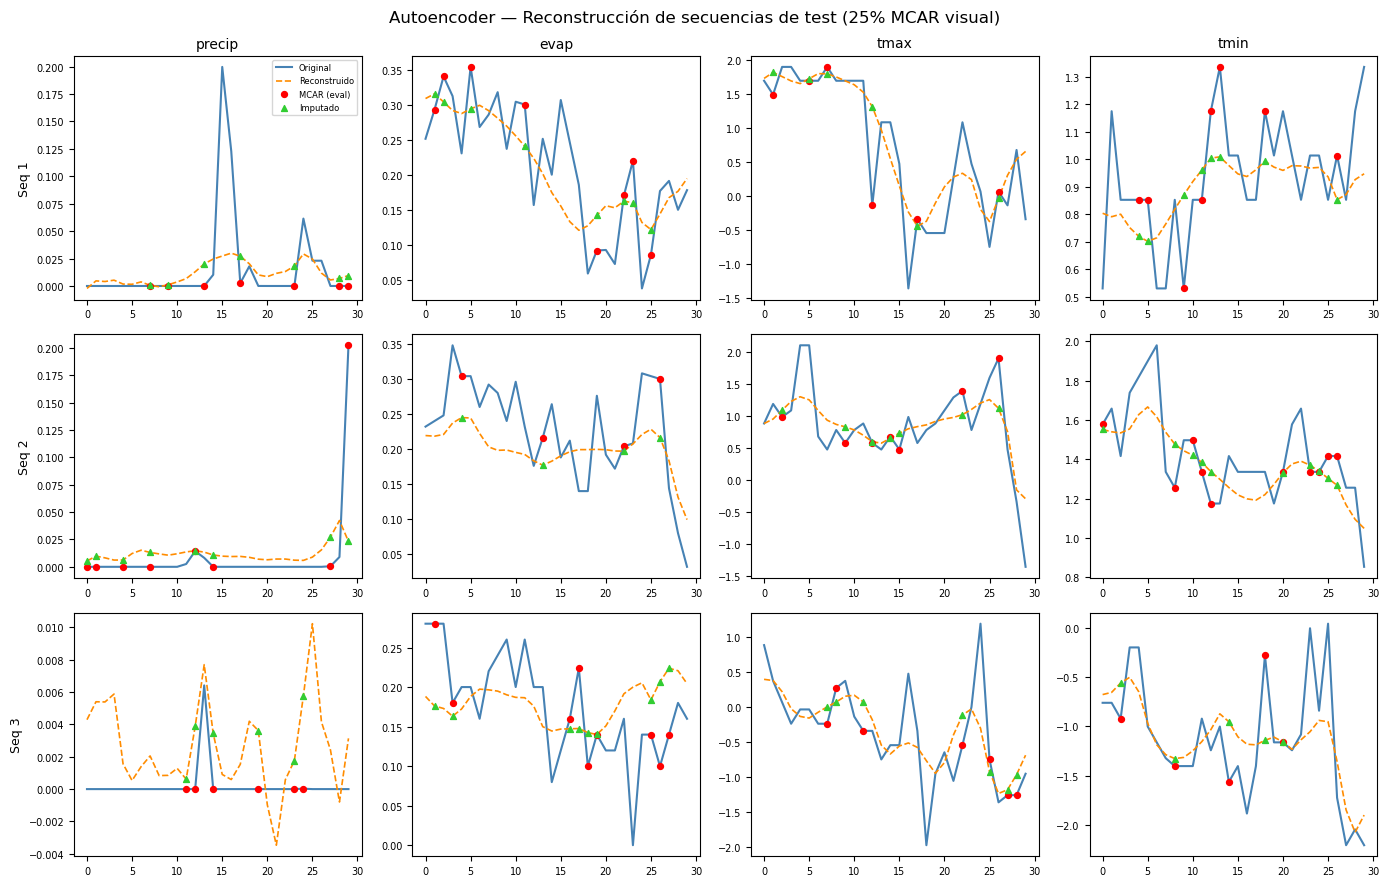

In [9]:
# Seleccionar 3 secuencias de test para mostrar reconstrucción
torch.manual_seed(0)
model.eval()

# Secuencias con obs_rate alto (pocas posiciones faltantes originales)
obs_rate = M_test.mean(dim=(1, 2))
high_obs  = torch.where(obs_rate > 0.90)[0]
sample_idx = high_obs[torch.randperm(len(high_obs))[:3]]

X_sample = X_test[sample_idx].to(DEVICE)
M_sample = M_test[sample_idx].to(DEVICE)

# MCAR artificial para visualización
rand    = torch.rand_like(M_sample)
ev_mask = M_sample * (rand > 0.25).float()
gt_mask = M_sample * (rand <= 0.25).float()
X_mcar  = X_sample * ev_mask

with torch.no_grad():
    recon = model(X_mcar).cpu()

X_sample = X_sample.cpu()
M_sample = M_sample.cpu()
ev_mask  = ev_mask.cpu()
gt_mask  = gt_mask.cpu()

fig, axes = plt.subplots(3, N_FEAT, figsize=(14, 9))
fig.suptitle('Autoencoder — Reconstrucción de secuencias de test (25% MCAR visual)',
             fontsize=12)
days = np.arange(WIN_SIZE)

for row, sidx in enumerate(range(3)):
    for col, var in enumerate(VARIABLES):
        ax = axes[row, col]
        orig  = X_sample[sidx, :, col].numpy()
        rec   = recon[sidx, :, col].numpy()
        gmask = gt_mask[sidx, :, col].bool().numpy()
        emask = ev_mask[sidx, :, col].bool().numpy()

        ax.plot(days, orig, 'steelblue', lw=1.5, label='Original')
        ax.plot(days, rec,  'darkorange', lw=1.2, ls='--', label='Reconstruido')
        ax.scatter(days[gmask], orig[gmask], color='red', zorder=5,
                   s=18, label='MCAR (eval)')
        ax.scatter(days[gmask], rec[gmask],  color='limegreen', zorder=6,
                   s=18, marker='^', label='Imputado')

        if row == 0:
            ax.set_title(var, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'Seq {sidx+1}', fontsize=9)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_reconstruccion.png", dpi=120, bbox_inches='tight')
plt.show()

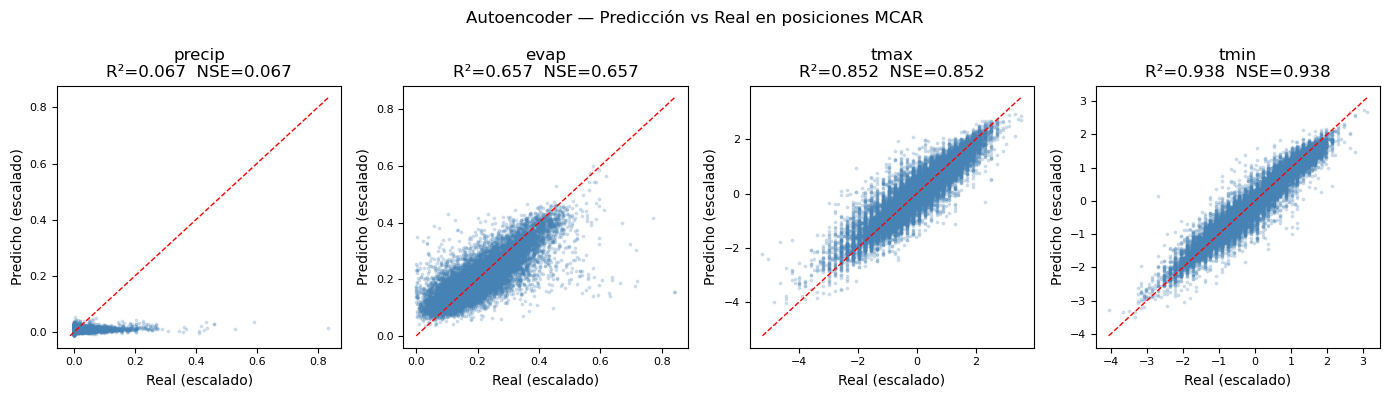

In [10]:
# Scatter plot predicción vs real por variable
fig, axes = plt.subplots(1, N_FEAT, figsize=(14, 4))
fig.suptitle('Autoencoder — Predicción vs Real en posiciones MCAR', fontsize=12)

torch.manual_seed(42)
with torch.no_grad():
    # Muestra de 5000 secuencias para scatter
    n_sample = min(5000, X_test.shape[0])
    idx = torch.randperm(X_test.shape[0])[:n_sample]
    Xs = X_test[idx]
    Ms = M_test[idx]
    rand = torch.rand_like(Ms)
    ev_m = Ms * (rand > MCAR_RATE).float()
    gt_m = Ms * (rand <= MCAR_RATE).float()
    Xs_masked = Xs * ev_m
    preds_s = model(Xs_masked.to(DEVICE)).cpu()

for fi, (ax, var) in enumerate(zip(axes, VARIABLES)):
    gm = gt_m[:, :, fi].bool()
    yt = Xs[:, :, fi][gm].numpy()
    yp = preds_s[:, :, fi][gm].numpy()
    lim = (min(yt.min(), yp.min()), max(yt.max(), yp.max()))
    ax.scatter(yt, yp, s=3, alpha=0.2, color='steelblue')
    ax.plot(lim, lim, 'r--', lw=1)
    m = compute_metrics(yt, yp, var)
    ax.set_title(f"{var}\nR²={m['r2']:.3f}  NSE={m['nse']:.3f}")
    ax.set_xlabel('Real (escalado)')
    ax.set_ylabel('Predicho (escalado)')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_scatter.png", dpi=120, bbox_inches='tight')
plt.show()

## 6 — Validación temporal: KPSS y ACF/PACF

Verificación de que la imputación preserva la **estructura estadística temporal**.
- **KPSS**: prueba de estacionariedad (H₀: estacionaria). Coherente si ambas series dan el mismo veredicto.
- **ACF/PACF**: autocorrelación original vs imputada en las posiciones observadas.

=== KPSS: Estacionariedad (H₀: estacionaria) ===
Variable  Stat_orig   p_orig    Stat_imp    p_imp     ¿Preserva?
─────────────────────────────────────────────────────────────────
precip    0.2287      0.1000    0.1491      0.1000    ✓ Sí
evap      0.1772      0.1000    0.1306      0.1000    ✓ Sí
tmax      0.4415      0.0593    0.4095      0.0731    ✓ Sí
tmin      0.1453      0.1000    0.1406      0.1000    ✓ Sí

KPSS guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/kpss_autoencoder.csv
ACF/PACF guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/acf_pacf_autoencoder.csv


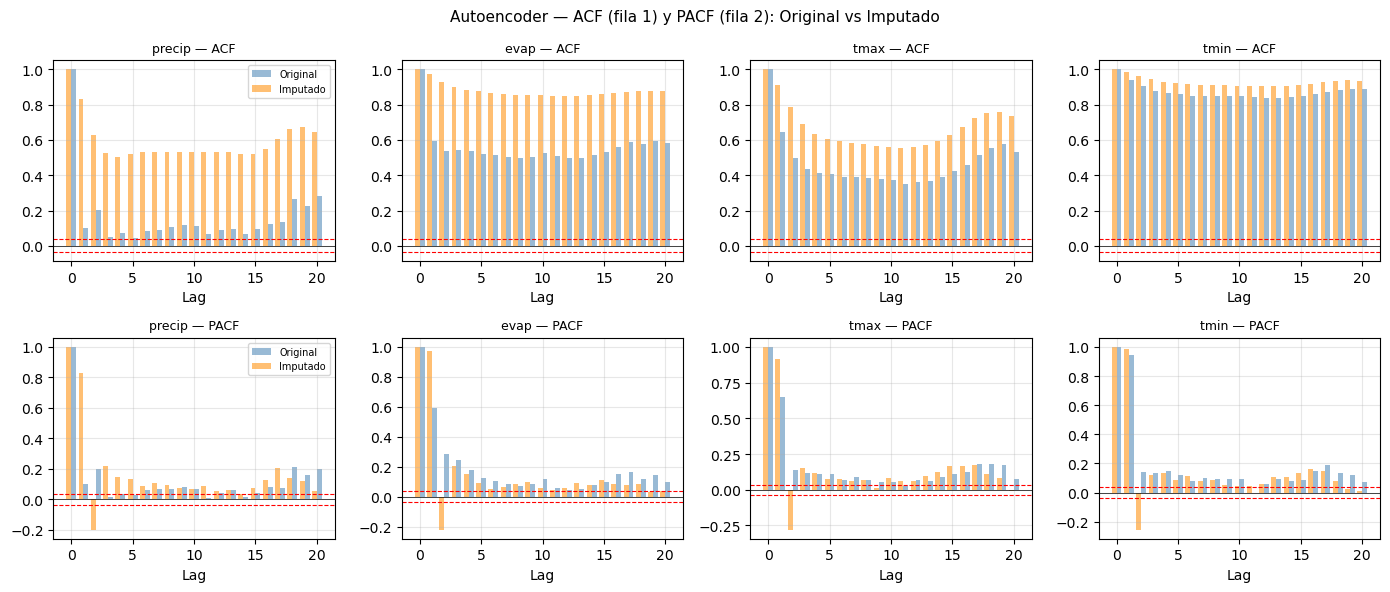

Validación temporal completada.


In [11]:
from statsmodels.tsa.stattools import kpss, acf, pacf
import warnings

N_LAGS = 20

# Restaurar variables de evaluación MCAR (sobreescritas en cell[14])
preds = _ae_preds
Xs    = _ae_Xs
ev_m  = _ae_ev_m

# ─── KPSS + ACF/PACF: calcular, mostrar y guardar ────────────────────────────
print("=== KPSS: Estacionariedad (H₀: estacionaria) ===")
print(f"{"Variable":<8}  {"Stat_orig":<10}  {"p_orig":<8}  {"Stat_imp":<10}  {"p_imp":<8}  {"¿Preserva?"}")
print("─" * 65)

kpss_rows, acf_rows = [], []

for fi, var in enumerate(VARIABLES):
    obs_m  = ev_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][obs_m].numpy()[:5000]
    y_pred = preds[:, :, fi][obs_m].numpy()[:5000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat_o, p_o, *_ = kpss(y_orig, regression="c", nlags="auto")
        stat_i, p_i, *_ = kpss(y_pred, regression="c", nlags="auto")
    preserva = bool((p_o > 0.05) == (p_i > 0.05))
    ok = "✓ Sí" if preserva else "✗ No"
    print(f"{var:<8}  {stat_o:<10.4f}  {p_o:<8.4f}  {stat_i:<10.4f}  {p_i:<8.4f}  {ok}")
    kpss_rows.append({"modelo": "Autoencoder", "variable": var,
                       "stat_orig": round(stat_o, 4), "p_orig": round(p_o, 4),
                       "stat_imp":  round(stat_i, 4), "p_imp":  round(p_i, 4),
                       "preserva_estacionariedad": preserva})

    n_s   = min(len(y_orig), 3000)
    acf_o = acf(y_orig[:n_s],  nlags=N_LAGS, fft=True)
    acf_i = acf(y_pred[:n_s],  nlags=N_LAGS, fft=True)
    pac_o = pacf(y_orig[:n_s], nlags=N_LAGS)
    pac_i = pacf(y_pred[:n_s], nlags=N_LAGS)
    for lag in range(N_LAGS + 1):
        acf_rows.append({"modelo": "Autoencoder", "variable": var, "lag": lag,
                          "acf_orig":  round(float(acf_o[lag]), 4),
                          "acf_imp":   round(float(acf_i[lag]), 4),
                          "pacf_orig": round(float(pac_o[lag]), 4),
                          "pacf_imp":  round(float(pac_i[lag]), 4)})

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_DIR / "kpss_autoencoder.csv", index=False)
print(f"\nKPSS guardado: {REPORTS_DIR / 'kpss_autoencoder.csv'}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_DIR / "acf_pacf_autoencoder.csv", index=False)
print(f"ACF/PACF guardado: {REPORTS_DIR / 'acf_pacf_autoencoder.csv'}")

# ─── Gráfica ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N_FEAT, figsize=(14, 6))
fig.suptitle("Autoencoder — ACF (fila 1) y PACF (fila 2): Original vs Imputado", fontsize=11)

for fi, var in enumerate(VARIABLES):
    sub  = df_acf[df_acf["variable"] == var].sort_values("lag")
    lags = sub["lag"].values
    ci   = 1.96 / (3000 ** 0.5)
    for row, (co, ci2, lbl) in enumerate([
            ("acf_orig", "acf_imp", "ACF"), ("pacf_orig", "pacf_imp", "PACF")]):
        ax = axes[row, fi]
        ax.bar(lags, sub[co],  alpha=0.55, color="steelblue",  label="Original", width=0.4,  align="edge")
        ax.bar(lags, sub[ci2], alpha=0.55, color="darkorange", label="Imputado", width=-0.4, align="edge")
        ax.axhline(0,  color="black", lw=0.5)
        ax.axhline( ci, color="red", lw=0.8, ls="--")
        ax.axhline(-ci, color="red", lw=0.8, ls="--")
        ax.set_title(f"{var} — {lbl}", fontsize=9)
        ax.set_xlabel("Lag"); ax.grid(alpha=0.3)
        if fi == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "acf_pacf_autoencoder.png", dpi=120, bbox_inches="tight")
plt.show()
print("Validación temporal completada.")



## 7 — Visualización del espacio latente

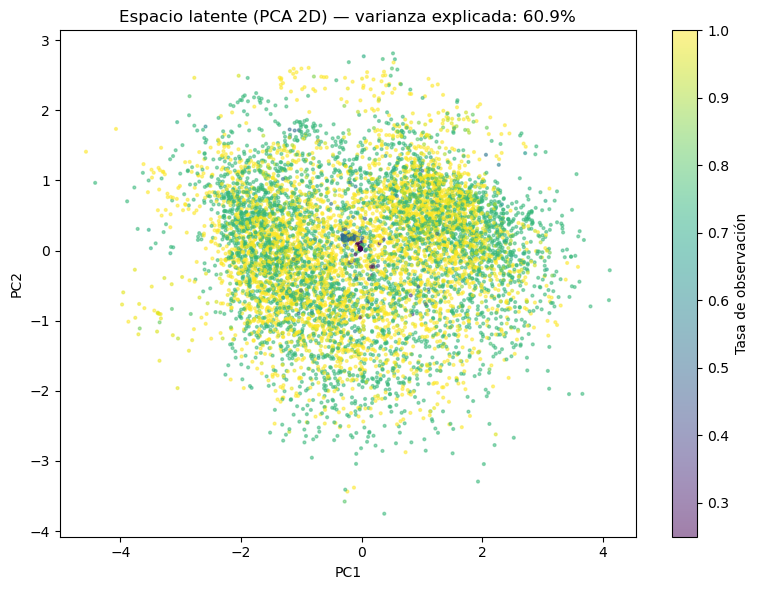

In [12]:
# Proyección 2-D del espacio latente con PCA
from sklearn.decomposition import PCA

model.eval()
n_lat = min(8000, X_test.shape[0])
idx_lat = torch.randperm(X_test.shape[0])[:n_lat]

with torch.no_grad():
    z_lat = model.encode(X_test[idx_lat].to(DEVICE)).cpu().numpy()

pca = PCA(n_components=2)
z2d = pca.fit_transform(z_lat)

# Colorear por tasa de observación de la secuencia
obs_r = M_test[idx_lat].mean(dim=(1, 2)).numpy()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z2d[:, 0], z2d[:, 1], c=obs_r, cmap='viridis',
                s=4, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Tasa de observación')
ax.set_title(f'Espacio latente (PCA 2D) — varianza explicada: '
             f'{pca.explained_variance_ratio_.sum()*100:.1f}%')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "autoencoder_espacio_latente.png", dpi=120, bbox_inches='tight')
plt.show()

## 8 — Guardado de métricas

In [13]:
rows = []
for var, m in ae_eval.items():
    row = dict(m)
    row['modelo'] = 'Autoencoder'
    rows.append(row)

metrics_ae = pd.DataFrame(rows)
metrics_ae.to_csv(REPORTS_DIR / "metrics_autoencoder.csv", index=False)

print("Métricas Autoencoder (MCAR 20%, espacio escalado):")
display(
    metrics_ae[["variable","n_mcar","rmse","mae","mape","r2","nse"]]
    .set_index("variable")
    .round(4)
)
print(f"\nGuardado en: {REPORTS_DIR / 'metrics_autoencoder.csv'}")

# ─── Merge KPSS + tablas de resumen ─────────────────────────────────────────
kpss_slim = df_kpss[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']].copy()
metrics_ae = metrics_ae.drop(columns=['stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad'], errors='ignore')
metrics_ae = metrics_ae.merge(kpss_slim, on='variable', how='left')
metrics_ae.to_csv(REPORTS_DIR / 'metrics_autoencoder.csv', index=False)
print('\n── Métricas de error y ajuste ──')
display(
    metrics_ae[['variable','n_mcar','rmse','mae','mape','r2','nse']]
    .set_index('variable').round(4)
)
print('\n── Estacionariedad KPSS ──')
kpss_display = df_kpss[['variable','p_orig','p_imp','preserva_estacionariedad']].copy()
kpss_display['veredicto_orig'] = kpss_display['p_orig'].apply(lambda p: 'Estacionaria' if p > 0.05 else 'No estacionaria')
kpss_display['veredicto_imp']  = kpss_display['p_imp'].apply( lambda p: 'Estacionaria' if p > 0.05 else 'No estacionaria')
kpss_display['preserva'] = kpss_display['preserva_estacionariedad'].map({True: '✓ Sí', False: '✗ No'})
display(kpss_display[['variable','veredicto_orig','veredicto_imp','preserva']].set_index('variable'))

Métricas Autoencoder (MCAR 20%, espacio escalado):


,n_mcar,rmse,mae,mape,r2,nse
variable,,,,,,
precip,196368,0.0222,0.0083,4.016534e+07,0.0664,0.0664
evap,100832,0.0580,0.0411,2.566685e+05,0.6628,0.6628
tmax,195614,0.3917,0.2781,8.213840e+01,0.8486,0.8486
tmin,195037,0.2561,0.1846,5.453790e+01,0.9365,0.9365



Guardado en: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_base/metrics_autoencoder.csv

── Métricas de error y ajuste ──


,n_mcar,rmse,mae,mape,r2,nse
variable,,,,,,
precip,196368,0.0222,0.0083,4.016534e+07,0.0664,0.0664
evap,100832,0.0580,0.0411,2.566685e+05,0.6628,0.6628
tmax,195614,0.3917,0.2781,8.213840e+01,0.8486,0.8486
tmin,195037,0.2561,0.1846,5.453790e+01,0.9365,0.9365



── Estacionariedad KPSS ──


,veredicto_orig,veredicto_imp,preserva
variable,,,
precip,Estacionaria,Estacionaria,✓ Sí
evap,Estacionaria,Estacionaria,✓ Sí
tmax,Estacionaria,Estacionaria,✓ Sí
tmin,Estacionaria,Estacionaria,✓ Sí


## 9 — Análisis de resultados y conclusiones

### Comportamiento esperado por variable
| Variable | Espacio | Dificultad |
|----------|---------|------------|
| `precip` | MinMaxScaler [0,1] | Alta — distribución muy asimétrica, 99.8% de ceros |
| `evap`   | MinMaxScaler [0,1] | Muy alta — faltantes estructurales (rachas ~3.6 años) |
| `tmax`   | StandardScaler (z-score) | Media — tendencia ascendente suave |
| `tmin`   | StandardScaler (z-score) | Media — correlación perfecta con tmax (r=1.0 en patrones de faltantes) |

### Ventajas del Autoencoder como baseline
- Aprende representación comprimida compartida entre las 4 variables → captura correlaciones cruzadas (tmax–evap).
- La máscara de pérdida permite entrenar con datos reales faltantes sin imputación previa.
- El espacio latente sirve como representación para diagnóstico y clustering de estaciones.

### Comparación frente a modelos generativos
El Autoencoder **no modela incertidumbre**: su salida es determinista. Los modelos generativos (VAE, GAIN, CSDI) añaden un componente estocástico que permite:
- Generar múltiples imputaciones plausibles.
- Cuantificar intervalos de confianza.
- Preservar mejor la varianza y los eventos extremos hidrológicos.

### Referencia de métricas (espacio escalado)
- `precip` / `evap` (MinMaxScaler): RMSE < 0.10 es buen resultado para el baseline.
- `tmax` / `tmin` (StandardScaler z-score): RMSE < 0.50 equivale a ~2.5–3 °C de error.
- NSE > 0.0: el modelo supera a predecir la media → umbral mínimo de utilidad.
- NSE > 0.6: buen desempeño para series hidrometeorológicas.
- **KPSS:** `preserva_estacionariedad = True` para todas las variables indica que la imputación no altera el régimen estacionario/no estacionario de la serie.
- **ACF/PACF:** correlogramas similares entre original e imputado confirman que la estructura de autocorrelación (periodicidades, decaimiento) se conserva.